# Capítulo 10: Integración Completa — Pipeline de Seguridad con IA

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 10.1. Introducción

Este capítulo integra **todos** los modelos entrenados en los capítulos anteriores en una
clase `PipelineSeguridad` que procesa un evento de red de extremo a extremo:

```
Evento de red
    │
    ├─ Isolation Forest (Cap.03) ──► anomalia_red
    ├─ Random Forest    (Cap.04) ──► malware_detectado
    ├─ SVM              (Cap.05) ──► severidad (0–3)
    ├─ UBA / Z-score    (Cap.06) ──► comportamiento_anomalo
    └─ Orquestador      (Cap.05) ──► acción automática
```

### Modelos cargados
| Archivo | Origen |
|---|---|
| `isolation_forest.pkl` + `scaler_red.pkl` | Cap. 03 |
| `random_forest_malware.pkl` + `malware_feature_cols.pkl` | Cap. 04 |
| `svm_severity.pkl` | Cap. 05 |
| `user_profiles.pkl` | Cap. 06 |

---
## Sección 10.0: Carga de todos los modelos

In [1]:
import joblib
import numpy as np
import pandas as pd
import logging
from pathlib import Path
from dataclasses import dataclass, field
from enum import IntEnum

MODELS_DIR = Path("../models")
DATA_DIR   = Path("../data")

# Cap. 03
model_if       = joblib.load(MODELS_DIR / "isolation_forest.pkl")
scaler_red     = joblib.load(MODELS_DIR / "scaler_red.pkl")

# Cap. 04
rf_malware     = joblib.load(MODELS_DIR / "random_forest_malware.pkl")
malware_cols   = joblib.load(MODELS_DIR / "malware_feature_cols.pkl")

# Cap. 05
svm_severity   = joblib.load(MODELS_DIR / "svm_severity.pkl")

# Cap. 06
user_profiles  = joblib.load(MODELS_DIR / "user_profiles.pkl")

print("Todos los modelos cargados correctamente:")
print(f"  Cap.03 → {type(model_if).__name__} + {type(scaler_red).__name__}")
print(f"  Cap.04 → {type(rf_malware).__name__} ({len(malware_cols)} features)")
print(f"  Cap.05 → {type(svm_severity).__name__}")
print(f"  Cap.06 → user_profiles ({len(user_profiles)} usuarios)")

Todos los modelos cargados correctamente:
  Cap.03 → IsolationForest + MinMaxScaler
  Cap.04 → RandomForestClassifier (12 features)
  Cap.05 → Pipeline
  Cap.06 → user_profiles (15 usuarios)


---
## Sección 10.1: Clase `PipelineSeguridad`

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(message)s"
)

FEAT_RED = ["bytes_sent", "bytes_recv", "duration", "src_port", "dst_port", "protocol"]
FEAT_UBA = ["hora_login", "bytes_sent", "failed_logins", "num_accesos_dia"]

class Severidad(IntEnum):
    BAJO    = 0
    MEDIO   = 1
    ALTO    = 2
    CRITICO = 3

@dataclass
class ResultadoAnalisis:
    anomalia_red         : int
    malware_detectado    : int
    severidad            : Severidad
    proba_severidad      : list
    alertas_uba          : list = field(default_factory=list)
    acciones             : list = field(default_factory=list)


class PipelineSeguridad:
    """
    Pipeline end-to-end de seguridad con IA.
    Integra detección de anomalías de red, malware, clasificación de severidad y UBA.
    """

    def __init__(self, model_if, scaler_red, rf_malware, malware_cols,
                 svm_severity, user_profiles, umbral_z_uba=3.0):
        self.model_if      = model_if
        self.scaler_red    = scaler_red
        self.rf_malware    = rf_malware
        self.malware_cols  = malware_cols
        self.svm_severity  = svm_severity
        self.user_profiles = user_profiles
        self.umbral_z      = umbral_z_uba

    # ── Etapa 1: anomalía de red (Cap.03) ─────────────────────────────────────
    def _detectar_anomalia_red(self, evento_red: dict) -> int:
        X = pd.DataFrame([{k: evento_red[k] for k in FEAT_RED}])
        X_scaled = self.scaler_red.transform(X)
        pred = self.model_if.predict(X_scaled)[0]
        return 1 if pred == -1 else 0

    # ── Etapa 2: detección de malware (Cap.04) ────────────────────────────────
    def _detectar_malware(self, features_archivo: dict) -> int:
        X = pd.DataFrame([{k: features_archivo.get(k, 0) for k in self.malware_cols}])
        return int(self.rf_malware.predict(X)[0])

    # ── Etapa 3: clasificación de severidad (Cap.05) ──────────────────────────
    def _clasificar_severidad(self, anomalia_red: int, malware: int,
                               contexto: dict) -> tuple:
        X = pd.DataFrame([{
            "anomalia_red"        : anomalia_red,
            "malware_detectado"   : malware,
            "num_hosts_afectados" : contexto.get("num_hosts", 1),
            "tipo_evento_cod"     : contexto.get("tipo_evento", 0),
            "bytes_exfiltrados"   : contexto.get("bytes_exfil", 0),
            "duracion_seg"        : contexto.get("duracion", 60),
            "privilegios_elevados": contexto.get("priv_elevados", 0),
        }])
        pred  = int(self.svm_severity.predict(X)[0])
        proba = self.svm_severity.predict_proba(X)[0].tolist()
        return Severidad(pred), proba

    # ── Etapa 4: UBA / Z-score (Cap.06) ──────────────────────────────────────
    def _analizar_comportamiento(self, user_id: str, evento_usuario: dict) -> list:
        if user_id not in self.user_profiles:
            return []
        perfil  = self.user_profiles[user_id]
        alertas = []
        for metrica, stats in perfil.items():
            if metrica not in evento_usuario:
                continue
            z = (evento_usuario[metrica] - stats["mean"]) / stats["std"]
            if abs(z) > self.umbral_z:
                alertas.append({"metrica": metrica, "z_score": round(z, 3)})
        return alertas

    # ── Etapa 5: orquestación de respuesta (Cap.05) ───────────────────────────
    def _orquestar(self, severidad: Severidad, ip: str, sistema: str) -> list:
        acciones = []
        if severidad >= Severidad.CRITICO:
            acciones.append(f"AISLAR_SISTEMA({sistema})")
        if severidad >= Severidad.ALTO:
            acciones.append(f"BLOQUEAR_IP({ip})")
        if severidad >= Severidad.MEDIO:
            acciones.append("NOTIFICAR_EQUIPO")
        if severidad == Severidad.BAJO:
            acciones.append("REGISTRAR_Y_MONITOREAR")
        return acciones

    # ── API principal ─────────────────────────────────────────────────────────
    def analizar(self, evento_red: dict, features_archivo: dict,
                 contexto: dict, user_id: str, evento_usuario: dict) -> ResultadoAnalisis:

        anomalia   = self._detectar_anomalia_red(evento_red)
        malware    = self._detectar_malware(features_archivo)
        sev, proba = self._clasificar_severidad(anomalia, malware, contexto)
        alertas    = self._analizar_comportamiento(user_id, evento_usuario)
        acciones   = self._orquestar(sev, evento_red.get("ip_origen","?"),
                                     contexto.get("sistema", "UNKNOWN"))

        logging.info(
            f"[PIPELINE] anomalia={anomalia} malware={malware} "
            f"sev={sev.name} uba_alerts={len(alertas)} "
            f"acciones={acciones}"
        )
        return ResultadoAnalisis(
            anomalia_red=anomalia, malware_detectado=malware,
            severidad=sev, proba_severidad=proba,
            alertas_uba=alertas, acciones=acciones
        )


pipeline = PipelineSeguridad(
    model_if, scaler_red, rf_malware, malware_cols,
    svm_severity, user_profiles
)
print("PipelineSeguridad instanciado correctamente.")

PipelineSeguridad instanciado correctamente.


---
## Sección 10.2: Demo end-to-end

Procesamos 4 escenarios representativos a través del pipeline completo.

In [3]:
from sklearn.preprocessing import LabelEncoder

# Necesitamos el encoder de protocolo del Cap.03
df_red = pd.read_csv(DATA_DIR / "network_traffic.csv")
le = LabelEncoder().fit(df_red["protocol"])

ESCENARIOS = [
    {
        "nombre"  : "Tráfico normal de oficina",
        "red"     : {"bytes_sent": 50_000, "bytes_recv": 120_000, "duration": 30,
                     "src_port": 55000, "dst_port": 443, "protocol": le.transform(["TCP"])[0],
                     "ip_origen": "192.168.1.10"},
        "archivo" : {col: 0 for col in malware_cols},   # benigno
        "contexto": {"num_hosts": 1, "tipo_evento": 0, "bytes_exfil": 0,
                     "duracion": 30, "priv_elevados": 0, "sistema": "WS-01"},
        "user"    : "user_01",
        "uba"     : {"hora_login": 9.0, "bytes_sent": 50_000, "failed_logins": 0, "num_accesos_dia": 5},
    },
    {
        "nombre"  : "Escaneo de puertos moderado",
        "red"     : {"bytes_sent": 200, "bytes_recv": 100, "duration": 1,
                     "src_port": 53210, "dst_port": 22, "protocol": le.transform(["TCP"])[0],
                     "ip_origen": "10.0.0.99"},
        "archivo" : {col: 0 for col in malware_cols},
        "contexto": {"num_hosts": 8, "tipo_evento": 0, "bytes_exfil": 0,
                     "duracion": 300, "priv_elevados": 0, "sistema": "WS-07"},
        "user"    : "user_03",
        "uba"     : {"hora_login": 14.0, "bytes_sent": 200, "failed_logins": 1, "num_accesos_dia": 3},
    },
    {
        "nombre"  : "Malware activo + tráfico C2",
        "red"     : {"bytes_sent": 5_000_000, "bytes_recv": 200_000, "duration": 7200,
                     "src_port": 4444, "dst_port": 4444, "protocol": le.transform(["TCP"])[0],
                     "ip_origen": "45.33.32.156"},
        "archivo" : {col: (8.0 if "entropia" in col else 5) for col in malware_cols},
        "contexto": {"num_hosts": 20, "tipo_evento": 3, "bytes_exfil": 3_000_000,
                     "duracion": 7200, "priv_elevados": 1, "sistema": "SRV-PROD-01"},
        "user"    : "user_05",
        "uba"     : {"hora_login": 3.0, "bytes_sent": 5_000_000, "failed_logins": 8, "num_accesos_dia": 1},
    },
    {
        "nombre"  : "Exfiltración masiva con privilegios",
        "red"     : {"bytes_sent": 9_000_000, "bytes_recv": 100_000, "duration": 3600,
                     "src_port": 1337, "dst_port": 443, "protocol": le.transform(["TCP"])[0],
                     "ip_origen": "91.108.4.1"},
        "archivo" : {col: (7.8 if "entropia" in col else 3) for col in malware_cols},
        "contexto": {"num_hosts": 45, "tipo_evento": 2, "bytes_exfil": 9_000_000,
                     "duracion": 3600, "priv_elevados": 1, "sistema": "SRV-DB-MAIN"},
        "user"    : "user_10",
        "uba"     : {"hora_login": 2.5, "bytes_sent": 9_000_000, "failed_logins": 0, "num_accesos_dia": 1},
    },
]

resultados = []
for esc in ESCENARIOS:
    res = pipeline.analizar(
        esc["red"], esc["archivo"], esc["contexto"],
        esc["user"], esc["uba"]
    )
    resultados.append(res)
    print(f"\n{'='*60}")
    print(f"Escenario : {esc['nombre']}")
    print(f"Anomalía red    : {'SI' if res.anomalia_red else 'no'}")
    print(f"Malware         : {'SI' if res.malware_detectado else 'no'}")
    print(f"Severidad       : {res.severidad.name} (proba {max(res.proba_severidad):.2f})")
    print(f"Alertas UBA     : {len(res.alertas_uba)} → {[a['metrica'] for a in res.alertas_uba]}")
    print(f"Acciones        : {res.acciones}")

Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
2026-05-06 23:58:48,368 INFO     [PIPELINE] anomalia=0 malware=0 sev=MEDIO uba_alerts=1 acciones=['NOTIFICAR_EQUIPO']
Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
2026-05-06 23:58:48,438 INFO     [PIPELINE] anomalia=0 malware=0 sev=MEDIO uba_alerts=1 acciones=['NOTIFICAR_EQUIPO']
Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
2026-05-06 23:58:48,514 INFO     [PIPELINE] anomalia=1 malware=1 sev=CRITICO uba_alerts=3 acciones=['AISLAR_SISTE


Escenario : Tráfico normal de oficina
Anomalía red    : no
Malware         : no
Severidad       : MEDIO (proba 0.89)
Alertas UBA     : 1 → ['hora_login']
Acciones        : ['NOTIFICAR_EQUIPO']

Escenario : Escaneo de puertos moderado
Anomalía red    : no
Malware         : no
Severidad       : MEDIO (proba 0.94)
Alertas UBA     : 1 → ['bytes_sent']
Acciones        : ['NOTIFICAR_EQUIPO']

Escenario : Malware activo + tráfico C2
Anomalía red    : SI
Malware         : SI
Severidad       : CRITICO (proba 0.97)
Alertas UBA     : 3 → ['hora_login', 'bytes_sent', 'failed_logins']
Acciones        : ['AISLAR_SISTEMA(SRV-PROD-01)', 'BLOQUEAR_IP(45.33.32.156)', 'NOTIFICAR_EQUIPO']

Escenario : Exfiltración masiva con privilegios
Anomalía red    : SI
Malware         : SI
Severidad       : CRITICO (proba 0.96)
Alertas UBA     : 2 → ['hora_login', 'bytes_sent']
Acciones        : ['AISLAR_SISTEMA(SRV-DB-MAIN)', 'BLOQUEAR_IP(91.108.4.1)', 'NOTIFICAR_EQUIPO']


---
## Sección 10.3: Dashboard de resultados

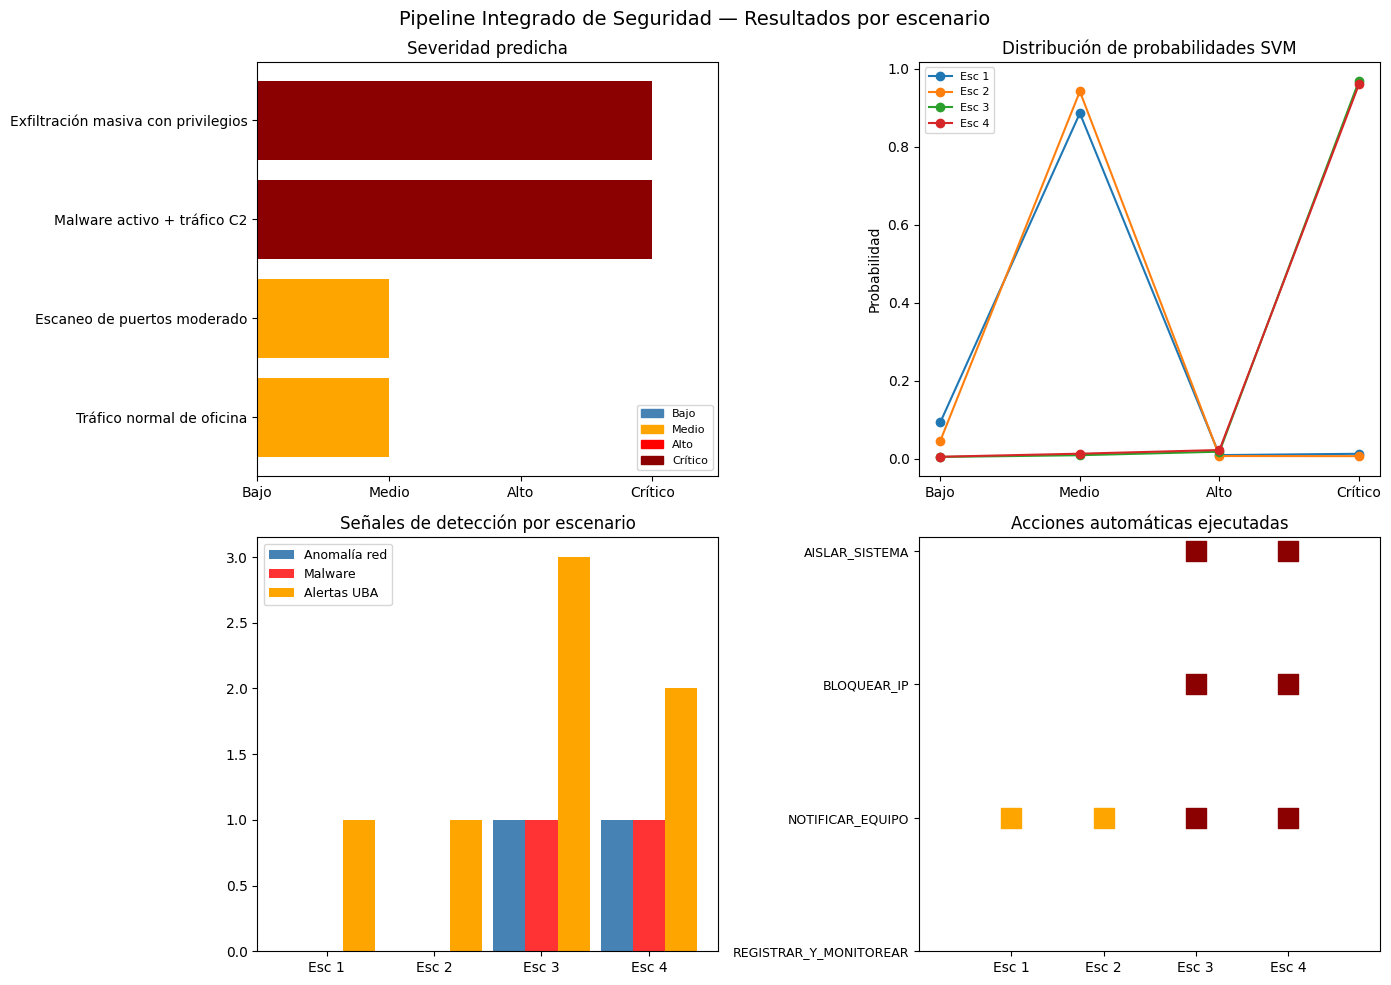

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

nombres    = [e["nombre"] for e in ESCENARIOS]
sev_vals   = [r.severidad.value for r in resultados]
anom_vals  = [r.anomalia_red for r in resultados]
mal_vals   = [r.malware_detectado for r in resultados]
uba_counts = [len(r.alertas_uba) for r in resultados]
sev_labels = ["Bajo","Medio","Alto","Crítico"]
sev_colors = ["steelblue","orange","red","darkred"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Pipeline Integrado de Seguridad — Resultados por escenario", fontsize=14)

# Severidad
colors = [sev_colors[s] for s in sev_vals]
bars = axes[0,0].barh(nombres, sev_vals, color=colors)
axes[0,0].set_xlim(0, 3.5)
axes[0,0].set_xticks([0,1,2,3])
axes[0,0].set_xticklabels(sev_labels)
axes[0,0].set_title("Severidad predicha")
patches = [mpatches.Patch(color=sev_colors[i], label=sev_labels[i]) for i in range(4)]
axes[0,0].legend(handles=patches, fontsize=8, loc="lower right")

# Probabilidades por escenario
x = np.arange(4)
for idx, (res, nombre) in enumerate(zip(resultados, nombres)):
    axes[0,1].plot(x, res.proba_severidad, marker="o", label=f"Esc {idx+1}")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(sev_labels)
axes[0,1].set_ylabel("Probabilidad")
axes[0,1].set_title("Distribución de probabilidades SVM")
axes[0,1].legend(fontsize=8)

# Señales de detección
x2 = np.arange(len(nombres))
w  = 0.3
axes[1,0].bar(x2 - w, anom_vals,  w, label="Anomalía red",  color="steelblue")
axes[1,0].bar(x2,     mal_vals,   w, label="Malware",        color="red",       alpha=0.8)
axes[1,0].bar(x2 + w, uba_counts, w, label="Alertas UBA",    color="orange")
axes[1,0].set_xticks(x2)
axes[1,0].set_xticklabels([f"Esc {i+1}" for i in range(len(nombres))])
axes[1,0].set_title("Señales de detección por escenario")
axes[1,0].legend(fontsize=9)

# Acciones tomadas
accion_map = {
    "REGISTRAR_Y_MONITOREAR": 1,
    "NOTIFICAR_EQUIPO"      : 2,
    "BLOQUEAR_IP"           : 3,
    "AISLAR_SISTEMA"        : 4,
}
for esc_idx, res in enumerate(resultados):
    for accion in res.acciones:
        clave = next((k for k in accion_map if accion.startswith(k)), None)
        if clave:
            axes[1,1].scatter(esc_idx + 1, accion_map[clave],
                               s=200, marker="s",
                               color=sev_colors[res.severidad.value])

axes[1,1].set_xticks(range(1, len(nombres)+1))
axes[1,1].set_xticklabels([f"Esc {i+1}" for i in range(len(nombres))])
axes[1,1].set_yticks(list(accion_map.values()))
axes[1,1].set_yticklabels(list(accion_map.keys()), fontsize=9)
axes[1,1].set_title("Acciones automáticas ejecutadas")
axes[1,1].set_xlim(0, len(nombres)+1)

import numpy as np
plt.tight_layout()
plt.savefig(DATA_DIR / "pipeline_dashboard.png", dpi=150)
plt.show()

---
## Persistencia del pipeline completo

In [5]:
joblib.dump(pipeline, MODELS_DIR / "pipeline_seguridad.pkl")

print("Pipeline completo guardado:")
print("  pipeline_seguridad.pkl  → contiene los 4 modelos integrados")
print()
print("Resumen de modelos persistidos en ../models/:")
for f in sorted(MODELS_DIR.glob("*.pkl")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:>8.1f} KB")

Pipeline completo guardado:
  pipeline_seguridad.pkl  → contiene los 4 modelos integrados

Resumen de modelos persistidos en ../models/:
  isolation_forest.pkl                       2474.2 KB
  malware_feature_cols.pkl                      0.2 KB
  pipeline_seguridad.pkl                     2761.2 KB
  random_forest_malware.pkl                   215.8 KB
  scaler_red.pkl                                1.2 KB
  svm_severity.pkl                             39.9 KB
  user_profiles.pkl                             3.2 KB


---
**Siguiente:** Capítulo 11 → Resumen y Perspectivas Futuras